# Exploratory Data Analysis (EDA)
**Objective:** Investigate target distribution, feature correlations, and categorical predictive power to inform Feature Engineering strategy.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load interim clean data
df = pd.read_csv('../data/interim/used_cars_cleaned.csv')

# Create a readable target column (Lakhs) for visualizations
df['AskPrice_Lakhs'] = df['AskPrice'] / 100000

### 1. Univariate Analysis: Target Variable (`AskPrice`)
*Investigating distribution shape, central tendency, and extreme outliers.*

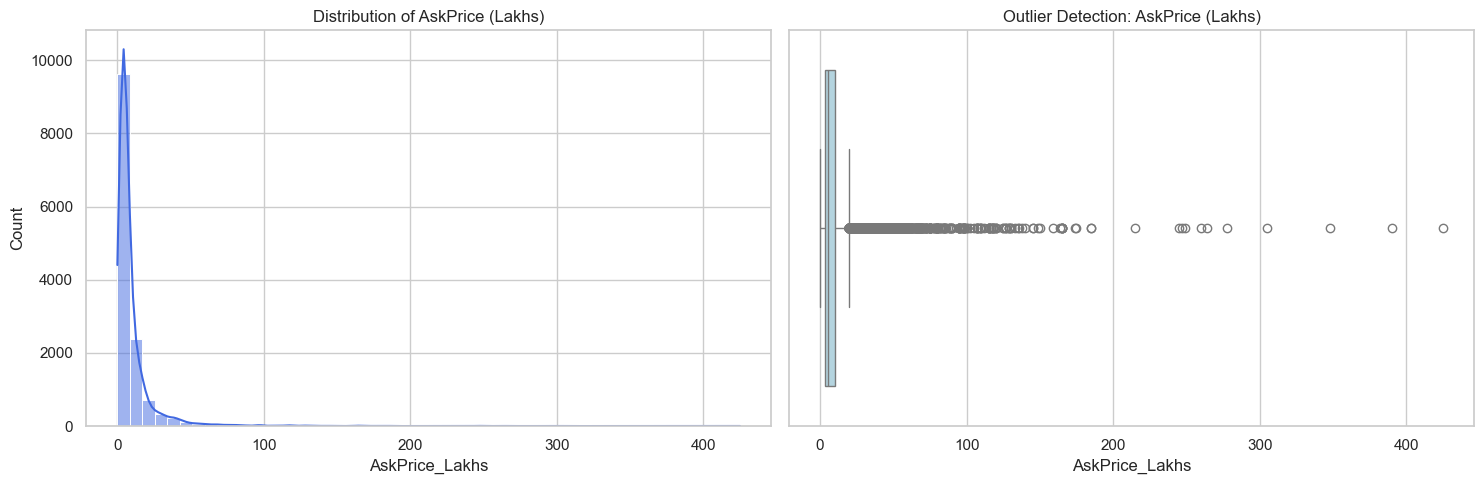

Mean: ₹985,186.31
Median: ₹560,000.50
Skewness: 8.393 (>1 indicates severe skew)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram + KDE
sns.histplot(df['AskPrice_Lakhs'], kde=True, ax=axes[0], color='royalblue', bins=50)
axes[0].set_title('Distribution of AskPrice (Lakhs)')

# Boxplot
sns.boxplot(x=df['AskPrice_Lakhs'], ax=axes[1], color='lightblue')
axes[1].set_title('Outlier Detection: AskPrice (Lakhs)')

plt.tight_layout()
plt.show()

# Print critical statistics
print(f"Mean: ₹{df['AskPrice'].mean():,.2f}")
print(f"Median: ₹{df['AskPrice'].median():,.2f}")
print(f"Skewness: {df['AskPrice'].skew():.3f} (>1 indicates severe skew)")


### 2. Bivariate Analysis: Numerical Features
*Analyzing linear correlations and identifying multicollinearity or leverage points.*

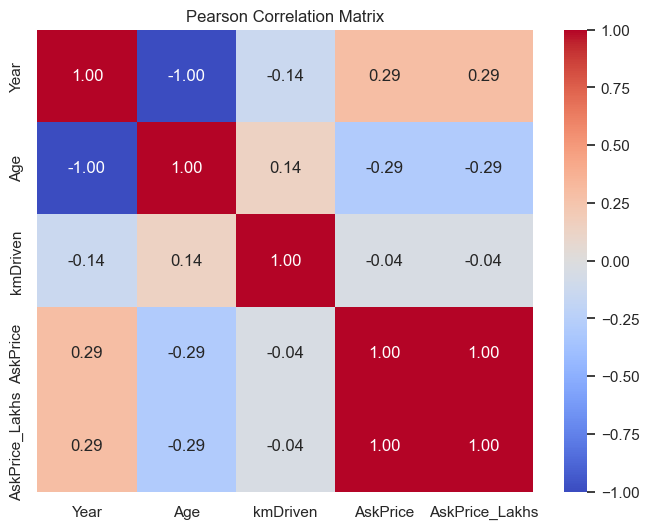

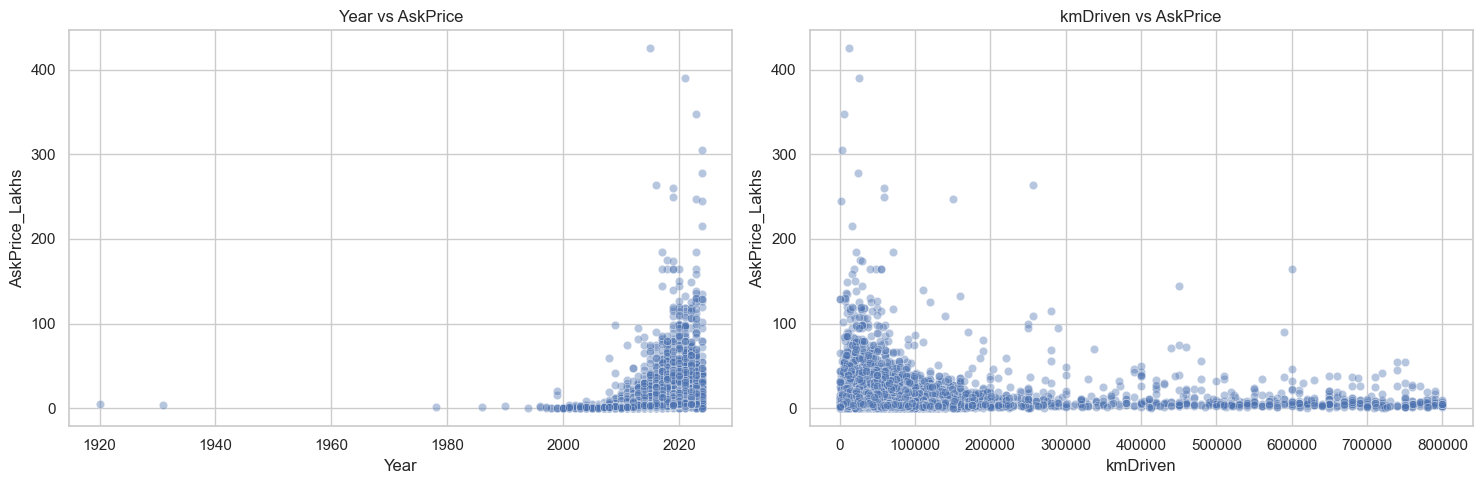

In [11]:
# Filter numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_numeric = df[numeric_cols]

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix')
plt.show()

# ACTION ITEM: Age and Year have -1.00 correlation (Multicollinearity). Drop one in Phase 5.

# Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='Year', y='AskPrice_Lakhs', ax=axes[0], alpha=0.4)
axes[0].set_title('Year vs AskPrice')
sns.scatterplot(data=df, x='kmDriven', y='AskPrice_Lakhs', ax=axes[1], alpha=0.4)
axes[1].set_title('kmDriven vs AskPrice')
plt.tight_layout()
plt.show()

# ACTION ITEM: Extreme X-axis outliers detected in Year (1920s) and kmDriven (800k+). Handle in Phase 5.

### 3. Categorical Analysis
*Evaluating predictive power via median variance across categories.*

C:\Users\Acer\AppData\Local\Temp\ipykernel_7448\3625575738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Transmission', y='AskPrice_Lakhs', ax=axes[0], palette='Set2')
C:\Users\Acer\AppData\Local\Temp\ipykernel_7448\3625575738.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='FuelType', y='AskPrice_Lakhs', ax=axes[1], palette='Set1')
C:\Users\Acer\AppData\Local\Temp\ipykernel_7448\3625575738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Brand'].isin(top_10_brands)], x='Brand', y='AskPrice_La

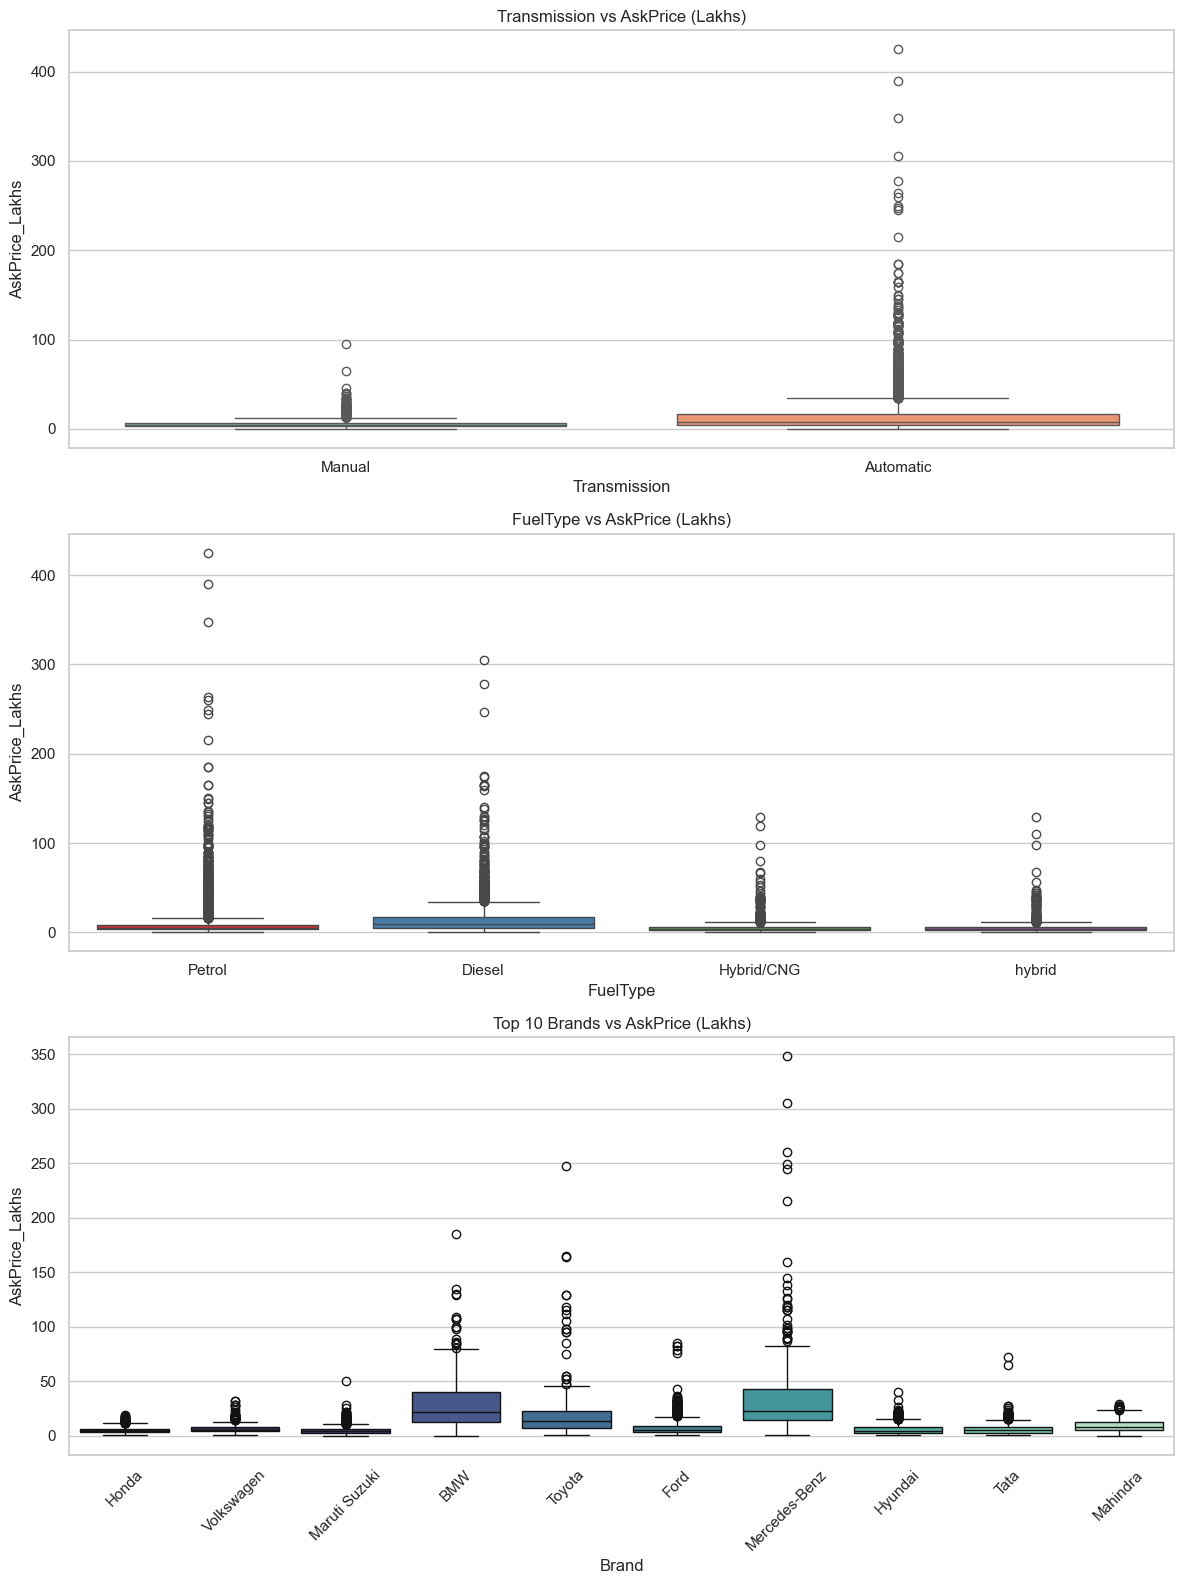

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# Transmission
sns.boxplot(data=df, x='Transmission', y='AskPrice_Lakhs', ax=axes[0], palette='Set2')
axes[0].set_title('Transmission vs AskPrice (Lakhs)')

# FuelType
sns.boxplot(data=df, x='FuelType', y='AskPrice_Lakhs', ax=axes[1], palette='Set1')
axes[1].set_title('FuelType vs AskPrice (Lakhs)')
# ACTION ITEM: Fix dirty data ('hybrid' vs 'Hybrid/CNG') in Phase 5.

# High Cardinality: Brand (Top 10)
top_10_brands = df['Brand'].value_counts().nlargest(10).index
sns.boxplot(data=df[df['Brand'].isin(top_10_brands)], x='Brand', y='AskPrice_Lakhs', ax=axes[2], palette='mako')
axes[2].set_title('Top 10 Brands vs AskPrice (Lakhs)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()